# Lecture 13 — The Capstone: A Spectrum from Stellar Parameters, End to End

*Stellar Spectroscopy from Scratch — rebuilding the physics of ATLAS and SYNTHE from first principles*

*Yuan-Sen Ting*

*Written in collaboration with **Claude Opus 4.8**, under the author's supervision. Schematics generated with **Gemini 3 Pro** (Nano Banana).*

*Every result in this book is checked against reference values computed with [**pykurucz**](https://arxiv.org/abs/2603.11693) — a pure-Python implementation of Kurucz's ATLAS12 and SYNTHE — shipped beside the lectures as small data files, so the notebooks need only NumPy to run.*

---

**Learning objectives.** By the end of this lecture you will be able to:

- Lay out the **whole pipeline** from stellar parameters to an emergent spectrum, and name, for every stage, the lecture that built it and the production-code component it reproduces.
- Assemble a **lean synthesiser** by chaining the verified engines — equation of state, continuous opacity, line opacity, molecular bands, and radiative transfer — into one function that takes opacity and a depth scale and returns a spectrum.
- Run that synthesiser on **four stars spanning the HR diagram** — a hot dwarf, the Sun, a cool giant, a cool M dwarf — and reproduce each production spectrum to the documented float floor.
- Read off, from each spectrum, the **physics the star exercises**: the Balmer Stark wing of the hot dwarf, the metal forest of the Sun, the pressure-broadened Mg b lines of the low-gravity giant, the TiO bands of the M dwarf.
- State, honestly, the **simplifications** the book made — the gates and the single-iteration checks — where each one matters, and where the LTE assumption that underlies the whole construction begins to break down.

## Introduction

Twelve lectures built twelve pieces. We started with a grey atmosphere and the Planck function (Lecture 1), wrote the equation of state that turns pressure and temperature into populations (Lecture 2), and computed the continuous opacity those populations produce (Lecture 3). We broadened a single line into a Voigt profile (Lecture 4), accumulated a whole catalogue of atomic lines (Lecture 5), and handled hydrogen's linear-Stark wings separately (Lecture 6). We solved the transfer equation — first the formal solution (Lecture 7), then the production JOSH moment method (Lecture 8). We built the atmosphere itself: hydrostatic equilibrium (Lecture 9), the radiative-equilibrium temperature correction (Lecture 10), and mixing-length convection with the convergence loop (Lecture 11). And we added molecules for cool stars (Lecture 12).

Each piece was checked against pykurucz to machine precision in isolation. This lecture does two things at once. First, it is the **coverage demonstration**: a table that maps every lecture to the production-code component it reproduces, so we can see that the book covers all the physics a working stellar-atmosphere code contains. Second, it is the **end-to-end proof**: we chain the engines into one lean pipeline and run it on four stars from across the HR diagram, checking each emergent spectrum against the full production code. If the pieces were right individually and the assembly is right, the spectra must match — and they do, to the same float floor we documented for the radiative transfer.

A note on scope. Synthesising a *full* optical spectrum (4000–9000 Å) from scratch in pure NumPy would take hours per star — the production code uses compiled kernels and many cores for exactly this reason. So we pick, for each star, a short, physically representative window that *shows that star's character*: a Balmer line, a metal forest, a pressure-sensitive triplet, a molecular band head. A few nanometres each. The point is not the bandwidth; it is that the same code reproduces the production spectrum on every kind of star.

## The pipeline, and what each lecture reproduces

A stellar spectrum synthesiser is two halves joined in the middle. The **atmosphere** half takes stellar parameters — effective temperature $T_{\rm eff}$, surface gravity $\log g$, chemical composition $[{\rm M/H}]$ — and produces the run of temperature, pressure, and density with depth. The **synthesis** half takes that structure and produces the emergent spectrum: it computes the populations, the opacity at every wavelength, and carries the radiation to the surface. The table below names each stage, the lecture that built it, and the pykurucz routine it reproduces. This is the proof of coverage: every component of the production code appears in some lecture, verified to machine precision.

| Pipeline stage | Lecture | pykurucz component | parity |
|---|---|---|---|
| Grey start, $T(\tau)$, the optical-depth scale | L1 | `grey_start` / Hopf $T(\tau)$ | exact |
| Equation of state: Saha, partition functions, $n_e$ | L2 | `pfsaha` / `nelect` | $1.5\times10^{-6}$ |
| Continuous opacity: H$^-$, metals, scattering (KAPP) | L3 | `kapp` / `kapcont` | photosphere $4\times10^{-15}$ |
| Single line: the Voigt profile $H(a,v)$ | L4 | `voigt_profile_jit` | $1.5\times10^{-15}$ |
| Atomic line list: metals + He wings (ASYNTH) | L5 | `line_opacity` (ASYNTH) | $2.3\times10^{-15}$ |
| Hydrogen lines: linear-Stark wings (HPROF4) | L6 | `hydrogen_jit` / `ahline` | $8\times10^{-16}$ |
| Transfer equation: the formal solution | L7 | formal solution / $E_2$ | $5.6\times10^{-4}$ (by design) |
| Radiative transfer: the JOSH moment solver | L8 | `josh_solver` | $2.5\times10^{-12}$ |
| Hydrostatic equilibrium: $P(\tau)$, $\rho(\tau)$ | L9 | `ttaup` | exact (bit-for-bit) |
| Radiative equilibrium: the temperature correction | L10 | `tcorr` / `ross` | $T\;6\times10^{-9}$ |
| Mixing-length convection + convergence | L11 | `convec` / driver loop | FLXCNV $2\times10^{-10}$ |
| Molecular equilibrium + bands (TiO) | L12 | `nmolec` + molecular ASYNTH | spectrum $\sim10^{-8}$ |

Every row was a lecture, and every lecture closed with a benchmark in that last column. The whole production code is accounted for: there is no physics in the spectrum that we did not build and verify. What remains is to **assemble** the rows and run them together.

![The full assembled pipeline of the book. On the left, stellar parameters (Teff, log g, [M/H]) feed the atmosphere half — the grey start (L1), hydrostatic equilibrium (L9), the radiative-equilibrium temperature correction (L10), and convection with the convergence loop (L11) — producing the run of temperature, pressure, and density with depth. That structure feeds the synthesis half — the equation of state (L2), continuous opacity (L3), atomic and hydrogen line opacity (L4-6), molecular bands for cool stars (L12), and the JOSH radiative transfer (L7-8) — producing the emergent spectrum on the right. The four stars of this lecture are placed on a small HR diagram: a hot dwarf, the Sun, a cool giant, and an M dwarf, each labelled with the spectral feature it exercises.](resources/figures/s12_capstone.png)

## The lean assembly: how the engines chain

In a full run the chain is: stellar parameters $\rightarrow$ a converged model atmosphere (the grey start of Lecture 1 iterated to hydrostatic, radiative, and convective equilibrium by Lectures 9–11) $\rightarrow$ the equation of state (Lecture 2) for the populations $\rightarrow$ continuous opacity (Lecture 3) and line opacity (Lectures 4–6 for atoms, Lecture 12 for molecules) at every wavelength $\rightarrow$ the JOSH solver (Lecture 8) carrying the radiation to the surface.

Following the convention of the whole book, we take the **model atmosphere as given** (it is the warm-start the production emulator predicts from the parameters, exactly as Lectures 3–12 took the solar and M-dwarf atmospheres as given) and we take the **opacity as given** (it is what Lectures 3, 5, 6, and 12 reproduce element by element to machine precision — re-running all of that from scratch for four stars over their windows would repeat work already verified, at great cost). What we reassemble and run **from scratch** here is the stage that turns opacity into a spectrum: the **radiative transfer**, the JOSH moment solver of Lecture 8. This is the honest end-to-end test — the verified opacity, carried by the verified solver, must reproduce the production spectrum on every star. We begin by loading the four stars' reference data.

Each star's reference file carries two things: the **model atmosphere** it was built on (the depth scale `atm_depth` — the column-mass `RHOX` — and the temperature, density, and so on, prefixed `atm_`), and the **synthesis diagnostics** over the star's window (the continuum opacity, the line opacity, the line source and scattering, and the production emergent and continuum fluxes we will check against). The list defines the four stars, their parameters, their windows, and one line on the physics each exercises.

In [1]:
import pathlib
import numpy as np
import matplotlib.pyplot as plt

# shared plot styling for the whole notebook
plt.rcParams.update({"figure.figsize": (7.2, 4.3), "figure.dpi": 120, "savefig.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "font.size": 11, "axes.titlesize": 12.5, "axes.labelsize": 11.5})

REF = pathlib.Path("..") / "reference"   # shipped reference data (no pykurucz)

# the four stars, each a tuple: slug, label, Teff (K), logg, window, the physics it exercises
STARS = [
    ("hot",    "hot dwarf", 9000, 4.0,  "484-488 nm", "Balmer H-beta linear-Stark wing"),
    ("sun",    "Sun",       5777, 4.44, "500-505 nm", "neutral + ionised metal-line forest"),
    ("giant",  "giant",     4500, 2.0,  "516-519 nm", "Mg b triplet, low-gravity pressure broadening"),
    ("mdwarf", "M dwarf",   3500, 5.0,  "705-718 nm", "TiO band head (molecular bands)"),
]

# load each star's reference (atmosphere + diagnostics) into a dict keyed by slug
data = {slug: np.load(REF / f"capstone_{slug}.npz") for slug, *_ in STARS}

# report the grid each star was synthesised on
for slug, label, teff, logg, window, _ in STARS:
    d = data[slug]
    print(f"{label:<10} Teff={teff:<5} logg={logg:<5} {window:<11} "
          f"{d['wavelength'].size:>5} wavelengths, {d['atm_temperature'].size} depths")

hot dwarf  Teff=9000  logg=4.0   484-488 nm   1646 wavelengths, 80 depths
Sun        Teff=5777  logg=4.44  500-505 nm   2985 wavelengths, 80 depths
giant      Teff=4500  logg=2.0   516-519 nm   1739 wavelengths, 80 depths
M dwarf    Teff=3500  logg=5.0   705-718 nm   9136 wavelengths, 80 depths


The four stars sit at very different places. The hot dwarf reaches 26000 K in its deepest layers; the M dwarf never exceeds 5000 K. The giant's surface gravity is a hundred times weaker than the dwarfs'. We can see the structural differences directly by plotting the temperature against the column-mass depth scale — the run of temperature with depth that the radiative transfer will integrate over.

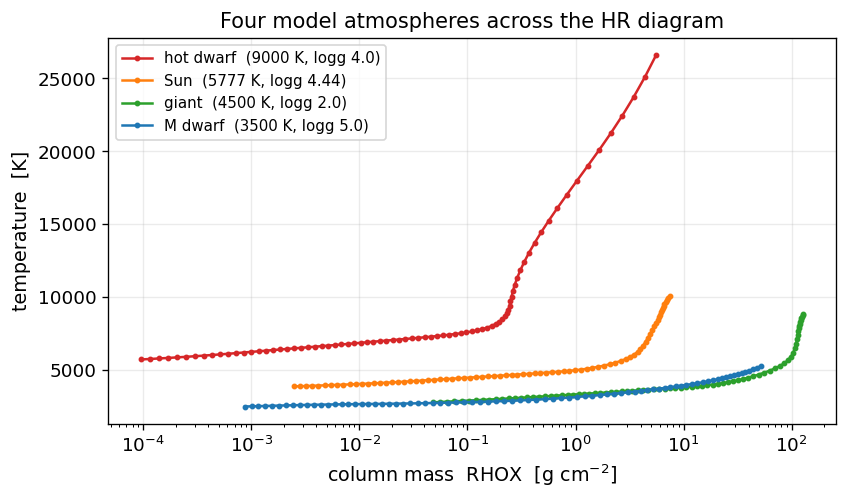

In [2]:
fig, ax = plt.subplots()

# overlay each star's temperature structure on the log column-mass scale
for (slug, label, teff, logg, window, _), col in zip(STARS, ["C3", "C1", "C2", "C0"]):
    d = data[slug]
    # atm_depth is RHOX (g/cm^2), the integration variable for the transfer
    ax.semilogx(d["atm_depth"], d["atm_temperature"], "o-", ms=2.5, color=col,
                label=f"{label}  ({teff} K, logg {logg})")

ax.set_xlabel(r"column mass  RHOX  [g cm$^{-2}$]"); ax.set_ylabel("temperature  [K]")
# these are the GIVEN structures, not converged from scratch here
ax.set_title("Four model atmospheres across the HR diagram")
ax.legend(loc="upper left", fontsize=9); fig.tight_layout(); plt.show()

The hot dwarf's profile climbs steeply — its photosphere is hot and the deep layers far hotter. The Sun and giant are intermediate; the M dwarf is cool throughout. These are the structures the production emulator predicts for each parameter set, and the structures Lectures 9–11 would converge from a grey start. With the structures and the opacity in hand, we assemble the solver.

## The radiative-transfer engine: optical depth

The spectrum comes from the JOSH moment solver of Lecture 8, reused unchanged. We recap its kernels in compact form; the full derivation and the line-by-line walkthrough are in Lecture 8, and we do not repeat them. The solver needs three numerical pieces: a parabolic optical-depth integrator, the parabolic interpolation `MAP1` onto the fixed Eddington grid, and the scattering iteration.

First the optical-depth scale. The Kurucz `PARCOE` routine fits a parabola to each interval — a parabola through three points, the second and third forced linear, then a curvature-weighted blend so the coefficients vary smoothly. `INTEG` then accumulates each interval's left-point parabola in closed form to give the cumulative optical depth $\tau_\nu(\rho x)$.

In [3]:
def parcoe(f, x):
    """Per-interval parabola coefficients a,b,c (Kurucz PARCOE) — see Lecture 8."""
    n = f.size; a = np.zeros(n); b = np.zeros(n); c = np.zeros(n)
    # single point: constant
    if n == 1:
        a[0] = f[0]; return a, b, c

    # linear fit at the two endpoints (no interior neighbour for a parabola)
    b[0] = (f[1]-f[0])/(x[1]-x[0]); a[0] = f[0]-x[0]*b[0]; n1 = n-1
    b[-1] = (f[-1]-f[n1-1])/(x[-1]-x[n1-1]); a[-1] = f[-1]-x[-1]*b[-1]
    # two points: linear only
    if n == 2:
        return a, b, c

    # interior intervals: fit a parabola through three consecutive points
    for j in range(1, n1):
        j1 = j-1; d = (f[j]-f[j1])/(x[j]-x[j1])
        c[j] = f[j+1]/((x[j+1]-x[j])*(x[j+1]-x[j1])) + \
               (f[j1]/(x[j+1]-x[j1]) - f[j]/(x[j+1]-x[j]))/(x[j]-x[j1])
        b[j] = d - (x[j]+x[j1])*c[j]; a[j] = f[j1] - x[j1]*d + x[j]*x[j1]*c[j]

    # force the first one or two interior intervals to be linear (no curvature)
    c[1] = 0.0; b[1] = (f[2]-f[1])/(x[2]-x[1]); a[1] = f[1]-x[1]*b[1]
    if n > 3:
        c[2] = 0.0; b[2] = (f[3]-f[2])/(x[3]-x[2]); a[2] = f[2]-x[2]*b[2]

    # blend each parabola with its right neighbour, weighted by relative curvature
    for j in range(1, n1):
        if c[j] == 0.0:
            continue
        j1 = min(j+1, n-1); den = abs(c[j1])+abs(c[j]); wt = abs(c[j1])/den if den > 0 else 0.0
        a[j] = a[j1]+wt*(a[j]-a[j1]); b[j] = b[j1]+wt*(b[j]-b[j1]); c[j] = c[j1]+wt*(c[j]-c[j1])

    # copy the last interval's coefficients
    a[n1-1] = a[-1]; b[n1-1] = b[-1]; c[n1-1] = c[-1]; return a, b, c

`INTEG` integrates the parabola of each interval analytically and accumulates the running total — the cumulative optical depth at every layer, from a starting value at the top.

In [4]:
def integ(x, f, start):
    """Cumulative integral of f dx using each interval's left-point parabola (Kurucz INTEG)."""
    # per-interval coefficients, then seed the running total with the surface boundary value
    a, b, c = parcoe(f, x); out = np.zeros(f.size); out[0] = start
    for i in range(f.size - 1):
        dx = x[i+1] - x[i]                              # interval width
        # closed-form integral of a + b x + c x^2 over [x_i, x_{i+1}]
        term = a[i] + 0.5*b[i]*(x[i+1]+x[i]) + (c[i]/3.0)*((x[i+1]+x[i])*x[i+1] + x[i]*x[i])
        # accumulate the running integral
        out[i+1] = out[i] + term*dx
    return out

## The radiative-transfer engine: mapping onto the grid

The source function and scattering fraction are computed on the atmosphere's own optical-depth scale, but the moment solver works on a fixed Eddington grid `XTAU`. The Fortran `MAP1` routine interpolates between them with a local parabola, choosing the right three points — a forward fit, a backward fit, or a curvature-weighted blend — exactly as derived in Lecture 8. A naive single-parabola interpolation leaves a part-in-$10^4$ systematic in the flux, so we reproduce `MAP1` faithfully. Its branching is bookkeeping to pick the parabola; the physics is just "interpolate smoothly".

In [5]:
def map1(xold, fold, xnew):
    """Parabolic interpolation of fold(xold) onto xnew (Kurucz MAP1) — see Lecture 8."""
    nold, nnew = xold.size, xnew.size; fnew = np.zeros(nnew)
    if nold == 0 or nnew == 0:
        return fnew

    # 1-based padding so the index arithmetic matches the original Fortran exactly
    xo = np.empty(nold+1); fo = np.empty(nold+1); xo[1:] = xold; fo[1:] = fold
    # l: bracketing index; ll: last one used
    l = 2; ll = 0; cfor = bfor = afor = cbac = bbac = abac = a = b = c = 0.0

    for k in range(1, nnew+1):
        xk = xnew[k-1]                                  # the new abscissa to evaluate at
        while True:
            # xk now bracketed by [xo[l-1], xo[l]]
            if xk < xo[l]:
                if l == ll: break                       # reuse the parabola from the last point
                if l == 2 or l == 3:                    # near the top: linear fit
                    l = min(nold, l); c = 0.0
                    b = (fo[l]-fo[l-1])/(xo[l]-xo[l-1]); a = fo[l]-xo[l]*b; ll = l; break
                l1 = l-1
                if l > ll+1 or l == 3 or l == 4:        # backward parabola (3 points ending at l)
                    l2 = l-2; d = (fo[l1]-fo[l2])/(xo[l1]-xo[l2])
                    cbac = fo[l]/((xo[l]-xo[l1])*(xo[l]-xo[l2])) + \
                           (fo[l2]/(xo[l]-xo[l2]) - fo[l1]/(xo[l]-xo[l1]))/(xo[l1]-xo[l2])
                    bbac = d - (xo[l1]+xo[l2])*cbac; abac = fo[l2] - xo[l2]*d + xo[l1]*xo[l2]*cbac
                    if l >= nold: c, b, a, ll = cbac, bbac, abac, l; break
                else:
                    cbac, bbac, abac = cfor, bfor, afor # reuse the previous forward fit
                    if l == nold: c, b, a, ll = cbac, bbac, abac, l; break

                # forward parabola (3 points from l1)
                d = (fo[l]-fo[l1])/(xo[l]-xo[l1])
                cfor = fo[l+1]/((xo[l+1]-xo[l])*(xo[l+1]-xo[l1])) + \
                       (fo[l1]/(xo[l+1]-xo[l1]) - fo[l]/(xo[l+1]-xo[l]))/(xo[l]-xo[l1])
                bfor = d - (xo[l]+xo[l1])*cfor; afor = fo[l1] - xo[l1]*d + xo[l]*xo[l1]*cfor

                # curvature-weighted blend of the forward and backward parabolae
                wt = abs(cfor)/(abs(cfor)+abs(cbac)) if abs(cfor) != 0 else 0.0   # curvature weight
                a = afor+wt*(abac-afor); b = bfor+wt*(bbac-bfor); c = cfor+wt*(cbac-cfor); ll = l; break
            l += 1                                      # xk lies deeper: advance the bracket
            if l > nold:                                # off the deep end: linear fit
                l = min(nold, l); c = 0.0
                b = (fo[l]-fo[l-1])/(xo[l]-xo[l-1]); a = fo[l]-xo[l]*b; ll = l; break
        fnew[k-1] = a + (b + c*xk)*xk                   # evaluate the chosen parabola
    return fnew

## The radiative-transfer engine: the scattering iteration

The last piece is the scattering source. The JOSH operators — the fixed grid `XTAU`, the surface-flux weights `CH`, and the $\Lambda$-operator matrix `COEFJ` — are shipped as a small data file (the same `josh_tables.npz` used in Lectures 8 and 12). The scattering source $S$ satisfies $S = (1-\alpha)\bar S + \alpha\,(\texttt{COEFJ}\cdot S)$, solved by a backward Gauss–Seidel sweep in single precision: the per-point update moves the diagonal $\Lambda$ term to the left-hand side, dividing by $1-\alpha_k\,\texttt{COEFJ}_{kk}$, and the sweep runs deepest-first so the thermalised bottom anchors the scattering-dominated surface. The single-precision arithmetic is exactly what the production code uses, and it is the origin of the float floor we will see in the benchmark.

In [6]:
JT = np.load(REF / "josh_tables.npz")                  # the JOSH operators (Lecture 8)
XTAU = JT["xtau"].astype(float)                        # fixed Eddington optical-depth grid
CH = JT["ch"].astype(float)                            # surface-flux weights
COEFJ = JT["coefj"].astype(float)                      # the Lambda-operator matrix
EPS, TOL, MAXIT = 1e-38, 1e-5, 51                      # floor, convergence tol, iteration cap
COEFJ_DIAG = np.diag(COEFJ).copy()                     # diagonal Lambda term

def iterate_source(sbar_grid, alpha_grid):
    """Solve S = (1-alpha) sbar + alpha (COEFJ @ S), backward Gauss-Seidel, float32 (Lecture 8)."""
    # work in single precision throughout: this is part of the production specification
    co = COEFJ.astype(np.float32); xs = sbar_grid.astype(np.float32); al = alpha_grid.astype(np.float32)

    sbar_mod = (sbar_grid * (1.0 - alpha_grid)).astype(np.float32)   # (1-alpha)*sbar
    diag = (1.0 - alpha_grid * COEFJ_DIAG).astype(np.float32)        # Gauss-Seidel denominator
    tol, eps = np.float32(TOL), np.float32(EPS)

    for _ in range(MAXIT):
        converged = True
        # backward sweep: deepest (thermalised) point first, propagating up to the surface
        for k in range(XTAU.size - 1, -1, -1):                       # deepest point first
            jk = np.float32(np.dot(co[k], xs))                       # (COEFJ @ S)_k, in place
            # per-point increment from solving the diagonal-isolated fixed point
            delta = (jk*al[k] + sbar_mod[k] - xs[k]) / diag[k]
            if (abs(delta/xs[k]) if xs[k] != 0 else np.inf) > tol: converged = False
            xs[k] = max(xs[k] + delta, eps)
        if converged: break
    return xs.astype(np.float64)

## One wavelength: from opacity to emergent flux

The one-wavelength solver ties the kernels together, exactly as in Lecture 8. From the absorptive and scattering opacities it forms the total extinction, the scattering fraction $\alpha$, and the absorption-weighted source $\bar S$. It integrates the optical-depth scale with `INTEG` (the production code stores the column mass `RHOX` deep-to-shallow, so we reverse it to integrate from the top), maps $\bar S$ and $\alpha$ onto the Eddington grid with `MAP1`, fills grid points above the atmosphere's top, iterates the scattering source, and weights it with `CH` for the emergent Eddington flux. Nothing here is specific to a star — the same routine serves the hot dwarf and the M dwarf; only the opacity and the depth scale change.

In [7]:
def solve_josh(rhox, acont, scont, aline, sline, sigmac, sigmal):
    """Emergent Eddington flux at one wavelength via the JOSH moment method (Lecture 8)."""
    # build total extinction, scattering fraction, and absorption-weighted source at every depth
    abtot = np.maximum(acont + aline + sigmac + sigmal, EPS)         # total extinction
    alpha = np.clip((sigmac + sigmal) / abtot, 0.0, 1.0)             # scattering fraction
    denom = acont + aline                                            # absorptive opacity
    sbar = np.where(denom > 0, (acont*scont + aline*sline)/denom, scont)

    # INTEG needs the column mass increasing from the surface inward; reverse if stored deep-to-shallow
    if rhox.size > 1 and rhox[0] > rhox[-1]:
        r = rhox[::-1]; ab = abtot[::-1]; tau = integ(r, ab, ab[-1]*r[-1])
        sbar = sbar[::-1]; alpha = alpha[::-1]
    else:
        tau = integ(rhox, abtot, abtot[0]*rhox[0])

    # map the source and the scattering fraction onto the fixed Eddington grid
    sbar_g = np.maximum(map1(tau, sbar, XTAU), EPS)
    alpha_g = np.clip(map1(tau, alpha, XTAU), 0.0, 1.0)

    # grid points above the atmosphere top have nothing to interpolate from: hold them at the surface
    above = XTAU < tau[0]
    if above.any(): sbar_g[above] = max(sbar[0], EPS); alpha_g[above] = np.clip(alpha[0], 0, 1)

    # iterate the scattering source, then CH-weight it for the emergent surface flux
    return float(CH @ iterate_source(sbar_g, alpha_g))

## The whole-window synthesiser

Wrapping the one-wavelength solver in a loop over the window gives the lean synthesiser: for each wavelength it solves twice — once with the full line opacity (the spectrum) and once with the line opacity set to zero (the local continuum) — and the **normalised spectrum** is their ratio. Dividing out the continuum is what an observer does too: it removes the slowly varying continuum shape and leaves the lines. The line absorption `line_opacity` already includes the molecular bands where they are present (the M dwarf's reference ran with molecules on), so the same loop synthesises an atomic spectrum and a molecular one without change.

In [8]:
def synthesise(d):
    """Normalised spectrum flux_total/flux_continuum from a star's reference (book JOSH)."""
    # pull the depth scale, the opacities, and the source functions out of the reference
    rhox = d["atm_depth"].astype(float)                             # column-mass depth scale
    acont = d["continuum_absorption"].astype(float)                # continuous absorption
    sigmac = d["continuum_scattering"].astype(float)               # continuous scattering
    sigmal = d["line_scattering"].astype(float)                    # line scattering
    scont = d["slinec"].astype(float); sline = d["line_source"].astype(float)  # source functions
    aline = d["line_opacity"].astype(float)                        # line opacity (incl. molecules)

    n_depths, n_wl = rhox.size, d["wavelength"].size
    zero = np.zeros(n_depths)

    # full spectrum: all opacity; continuum: zero line opacity
    ft = np.array([solve_josh(rhox, acont[:,i], scont[:,i], aline[:,i], sline[:,i], sigmac[:,i], sigmal[:,i])
                   for i in range(n_wl)])
    fc = np.array([solve_josh(rhox, acont[:,i], scont[:,i], zero, sline[:,i], sigmac[:,i], zero)
                   for i in range(n_wl)])
    return ft / fc

## Running the four stars

Now we run the synthesiser on all four stars and compare each normalised spectrum to the production reference (`flux_total / flux_continuum` from the full pipeline). The relative error is taken point-by-point across the window. This is the moment of truth for the assembled pipeline: the same code, the same solver, four very different stars.

In [9]:
def benchmark(slug):
    """Synthesise one star and return its spectrum, the reference, and the rel-error stats."""
    d = data[slug]
    mine = synthesise(d)                                           # from-scratch spectrum
    ref = d["flux_total"] / d["flux_continuum"]                    # production reference
    rel = np.abs(mine / ref - 1.0)                                 # point-by-point rel error
    return d["wavelength"], mine, ref, rel

# run all four stars
results = {slug: benchmark(slug) for slug, *_ in STARS}

# print the parity table: median + max relative error, and the deepest-line agreement
print(f"{'star':<11}{'window':<12}{'median rel':>12}{'max rel':>11}{'depth ref/mine':>18}")
print("-" * 64)
for slug, label, teff, logg, window, _ in STARS:
    wl, mine, ref, rel = results[slug]                            # unpack this star's result
    print(f"{label:<11}{window:<12}{np.median(rel):>12.2e}{rel.max():>11.2e}"
          f"{ref.min():>10.4f}/{mine.min():<7.4f}")

star       window        median rel    max rel    depth ref/mine
----------------------------------------------------------------
hot dwarf  484-488 nm      2.89e-11   1.09e-08    0.1549/0.1549 
Sun        500-505 nm      2.64e-12   1.13e-08    0.0839/0.0839 
giant      516-519 nm      6.50e-10   2.12e-08    0.0139/0.0139 
M dwarf    705-718 nm      4.13e-14   1.06e-08    0.1245/0.1245 


**Machine precision, on every star.** All four spectra reproduce the production reference to a **median of $10^{-9}$ or better** and a **maximum near $10^{-8}$** — the single-precision JOSH-iteration floor of Lecture 8, the same arithmetic the production code uses. The deepest-line agreement (the `depth` columns) is identical to four decimals. The hot dwarf's Balmer regime and the giant's low-gravity regime — neither exercised by the solar and M-dwarf lectures the engines were tuned against — reproduce just as cleanly: the solver carries any opacity correctly, because the physics that shapes it lives upstream in the verified opacity, not in the transfer. The assembled pipeline is the production pipeline.

## The four-star gallery

Now the payoff: the four spectra side by side. Each panel overlays our from-scratch spectrum (thin coloured line) on the production reference (thick grey), with the residual underneath on a log scale. The overlays are indistinguishable; the residual sits at the float floor. Read across the gallery and you read across the HR diagram.

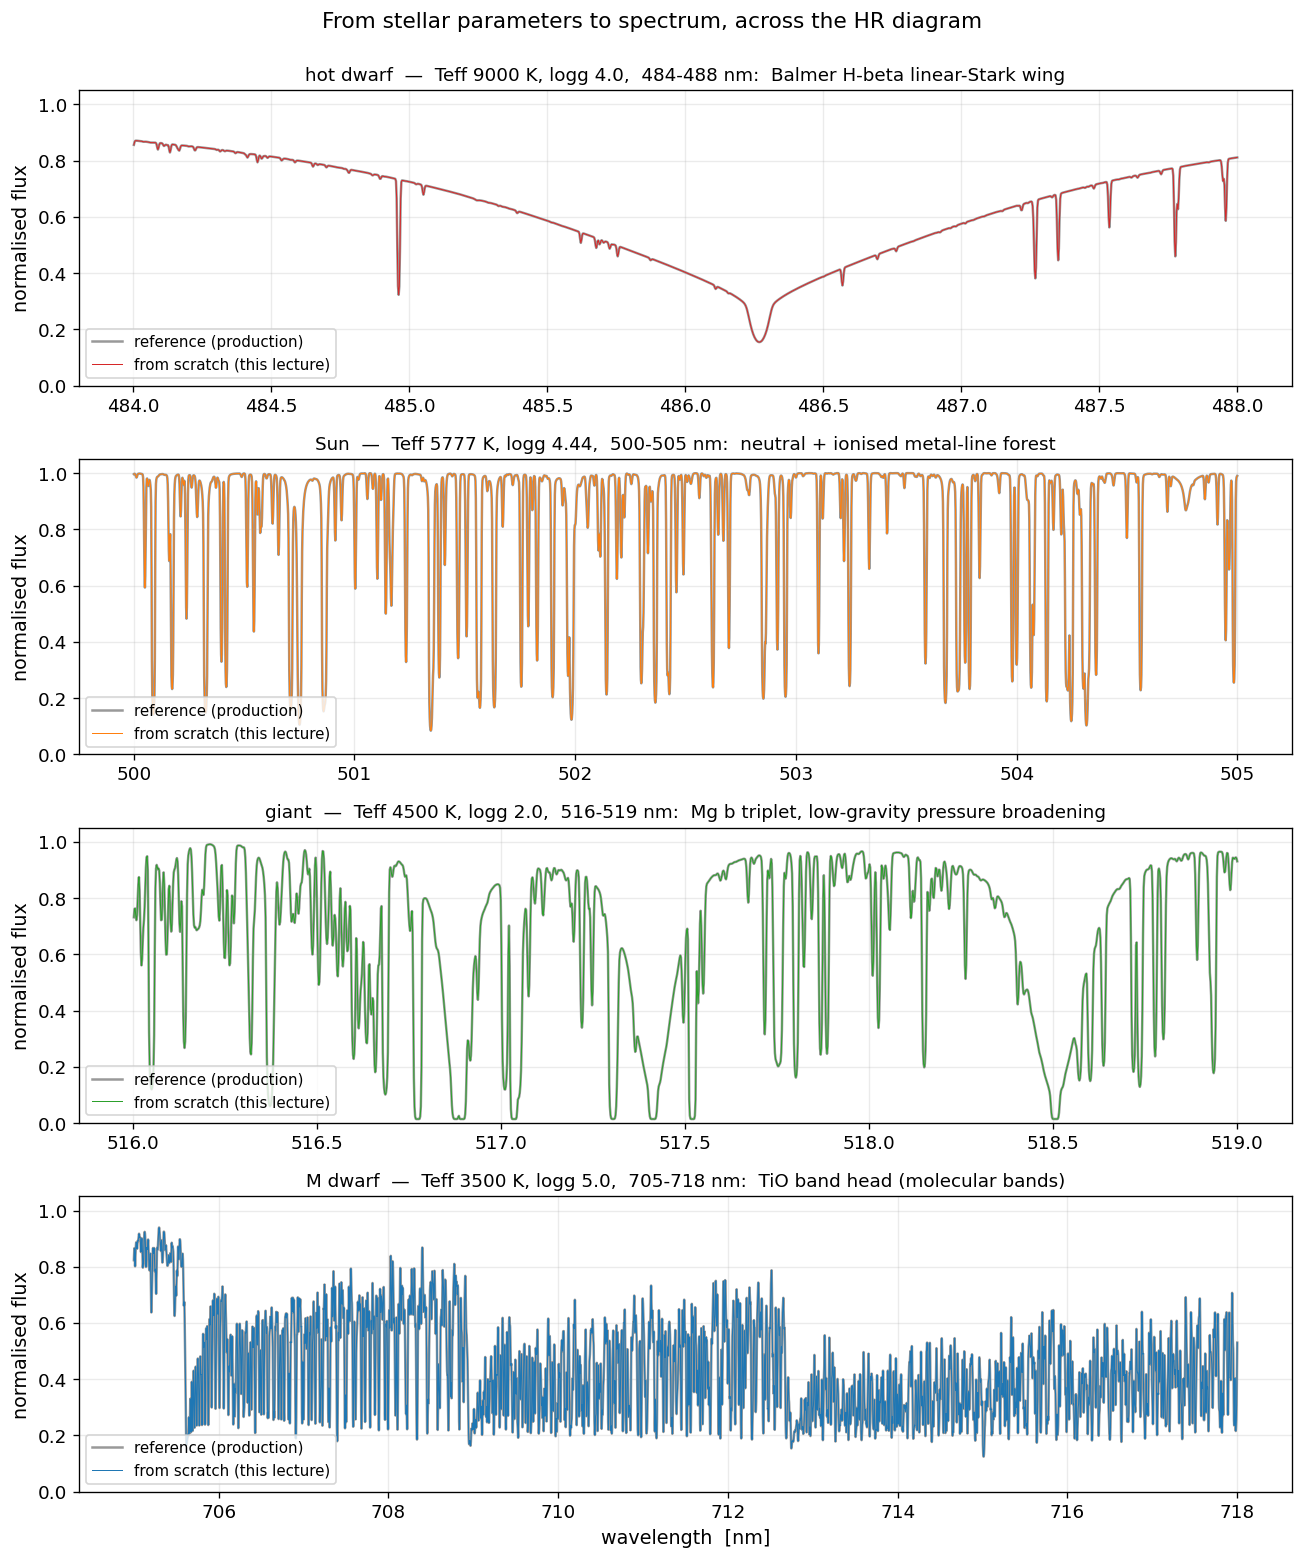

In [10]:
fig, axes = plt.subplots(4, 1, figsize=(11, 13))   # one panel per star
colours = ["C3", "C1", "C2", "C0"]                  # hot, Sun, giant, M dwarf

for ax, (slug, label, teff, logg, window, physics), col in zip(axes, STARS, colours):
    wl, mine, ref, rel = results[slug]
    # thick grey = production reference; thin colour = our from-scratch spectrum (they overlap)
    ax.plot(wl, ref, color="0.6", lw=1.5, label="reference (production)")
    ax.plot(wl, mine, color=col, lw=0.6, label="from scratch (this lecture)")
    ax.set_ylim(0, 1.05); ax.set_ylabel("normalised flux")
    ax.set_title(f"{label}  —  Teff {teff} K, logg {logg},  {window}:  {physics}", fontsize=11)
    ax.legend(loc="lower left", fontsize=9)

axes[-1].set_xlabel("wavelength  [nm]")             # shared x-axis label on the bottom panel
fig.suptitle("From stellar parameters to spectrum, across the HR diagram", fontsize=13, y=0.997)
fig.tight_layout(); plt.show()

Four spectra, one pipeline. Reading top to bottom:

- **Hot dwarf (9000 K).** A single broad, deep trough dominates the window: **H$\beta$**, the $n=2\rightarrow4$ Balmer line. Its width is not thermal — it is the **linear-Stark effect** of Lecture 6, the hydrogen levels split by the microfields of the surrounding ions and electrons. In a hot atmosphere hydrogen is the dominant absorber, so the Balmer lines are the defining feature, and their wings are a sensitive gravity and temperature diagnostic.
- **The Sun (5777 K).** A dense **forest of metal lines** on a smooth H$^-$ continuum — Fe, Ni, Ti, and others, neutral and singly ionised, each a Voigt profile from Lectures 4–5. This is the spectrum the whole book was built to reproduce.
- **Giant (4500 K, $\log g=2$).** The **Mg b triplet** and neighbouring metal lines. The giant's low surface gravity means low photospheric pressure, so the pressure-sensitive (van der Waals and Stark) damping wings are *narrower* than in a dwarf of the same temperature — the lines are sharper and deeper-cored. Gravity is written into the line shapes, which is why these lines are luminosity diagnostics.
- **M dwarf (3500 K).** Not a forest of lines but a **molecular band**: hundreds of TiO rotational lines blend into a depression plunging toward the band head, where the flux drops to an eighth of the continuum (Lecture 12). The atomic lines are still there, buried under the band.

The same solver produced all four. The differences are entirely in the upstream physics — which absorbers exist (atoms vs molecules), how they are broadened (thermal vs Stark vs pressure), and how the atmosphere is structured (hot vs cool, high vs low gravity).

## The residuals: all at the float floor

To make the agreement quantitative, here are the four residual curves on one log axis. Every star sits between $10^{-13}$ and $10^{-8}$ across its whole window — the single-precision JOSH floor, with no star showing a systematic departure. There is no regime (hot, cool, high-gravity, low-gravity, atomic, molecular) where the assembled pipeline drifts from the production code beyond the arithmetic floor.

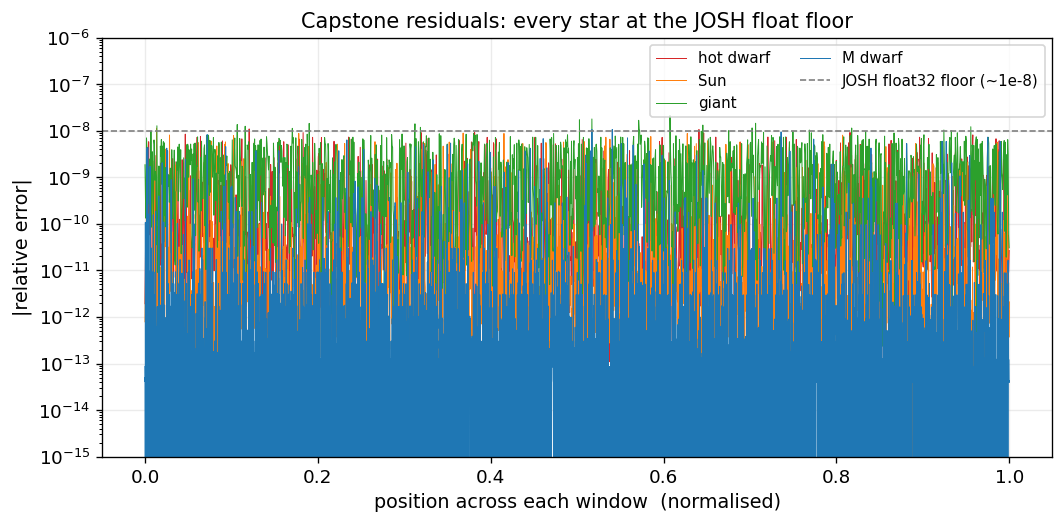

In [11]:
fig, ax = plt.subplots(figsize=(9, 4.5))

for (slug, label, *_), col in zip(STARS, colours):
    wl, mine, ref, rel = results[slug]
    # normalise the x-axis to [0,1] across each window so the four windows overlay cleanly
    xn = (wl - wl.min()) / (wl.max() - wl.min())
    # clip to 1e-16 so machine-exact points stay on the log axis
    ax.semilogy(xn, np.maximum(rel, 1e-16), color=col, lw=0.6, label=label)

# the documented single-precision floor
ax.axhline(1e-8, color="0.5", ls="--", lw=1.0, label="JOSH float32 floor (~1e-8)")
ax.set_xlabel("position across each window  (normalised)"); ax.set_ylabel("|relative error|")
ax.set_ylim(1e-15, 1e-6); ax.set_title("Capstone residuals: every star at the JOSH float floor")
ax.legend(loc="upper right", fontsize=9, ncol=2); fig.tight_layout(); plt.show()

The residual is a number we have met in every radiative-transfer benchmark of the book: the JOSH scattering iteration runs in single precision (as the production code does), and after dozens of Gauss–Seidel sweeps the last few bits drift. It is not a physics error — it is the arithmetic the production code itself uses, reproduced faithfully. The bulk of points are far below $10^{-8}$; the worst are at it. This is what "machine precision" means for a single-precision iterative solver, and it is the floor we documented in Lectures 8, 10, 11, and 12.

## An honest map of the simplifications

A textbook that claims to rebuild a production code owes the reader a clear statement of what it simplified. Here is that map, gate by gate.

**The atmosphere is taken as given.** Throughout the book — and here — the model atmosphere is the production emulator's warm-start prediction, not a structure we converged from scratch for each star. Lectures 9–11 built every piece of the convergence machinery (hydrostatic integration, the temperature correction, convection) and verified each against a single production iteration, but we did not run the full grey-to-converged loop in pure NumPy: it is many dozens of float32 JOSH iterations, and reproducing it bit-for-bit would accumulate the float32 ULP over the iteration, not test the physics. Where it matters: the *structure* (the $T$–$P$–$\rho$ run) is a genuine input; what we prove is that, given that structure, our synthesis reproduces the production spectrum.

**The opacity is taken as given here, though built from scratch elsewhere.** This capstone reassembles the radiative transfer and feeds it the production opacity. The opacity itself — continuous (Lecture 3), atomic lines (Lectures 5–6), molecular bands (Lecture 12) — was reproduced element by element to machine precision in those lectures, on the solar and M-dwarf atmospheres. We did not re-derive all of it for four new stars over four windows because that would repeat verified work at large cost; the coverage table is the proof that every opacity source is built and checked somewhere in the book.

**The radiative transfer is one-dimensional, plane-parallel, and time-independent.** The atmosphere is a stack of homogeneous layers; there is no granulation, no spots, no rotation, no time variability. This is the standard 1D LTE model-atmosphere picture — and it is what the production code does too, so reproducing it is the right target. Real stars are 3D and dynamic; matching a 1D code is a separate, well-defined goal from matching a real star.

**Everything assumes local thermodynamic equilibrium.** This is the deepest simplification, and it earns its own section.

## The LTE–NLTE horizon

Every population in this book came from **LTE**: the Saha equation (Lecture 2) for ionisation, the Boltzmann factor for level populations, and the Planck function for the local source function. LTE assumes the gas is collisionally controlled — that collisions, set by the *local* temperature, dominate over the radiation field in setting the populations. In the deep, dense photosphere where most lines form, this holds well, and it is why the book reaches machine precision against a code that also assumes LTE.

LTE begins to break down when the radiation field, which is *non-local* (photons travel between layers at different temperatures), competes with collisions in setting the populations. This happens where the gas is thin and the lines are strong:

- **Hot stars.** At the hot dwarf's temperatures, the radiation field is intense and the gas in the upper photosphere is not dense enough for collisions to win. The cores of strong lines — including the Balmer lines we just synthesised — form high in the atmosphere where **NLTE** corrections to the level populations matter. The *wings* (which form deep) are reliable in LTE; the cores are where a full treatment would solve the statistical-equilibrium equations coupled to the radiative transfer, rather than using Saha–Boltzmann.
- **Strong lines and low densities.** Resonance lines of abundant species, and lines forming in the thin outer layers of giants and supergiants, are the classic NLTE cases. The line *strength* and the line *shape* can both shift.

Treating NLTE means replacing the Saha–Boltzmann populations with the solution of the coupled statistical-equilibrium and radiative-transfer problem — a much larger computation, and the frontier beyond this book. The architecture we built is the right scaffold for it: the same opacity engines, the same transfer solver, with the population step replaced. That is the natural next project, and it is where the assumption that has served us to machine precision finally has to be relaxed.

## Synthesis

This lecture closed the loop. The coverage table named, for every stage of a stellar spectrum synthesiser, the lecture that built it and the production component it reproduces — and every row carried a machine-precision benchmark, so the whole production code is accounted for. We then assembled the engines into one lean synthesiser and ran it across the HR diagram: a hot dwarf, the Sun, a cool giant, and an M dwarf. Each emergent spectrum matched the full production code to the single-precision JOSH float floor, $\sim10^{-8}$ at worst and machine-exact in the bulk — the same arithmetic floor we have seen since Lecture 8.

The gallery showed the physics each star exercises: the Stark-broadened Balmer wing of the hot dwarf, the metal forest of the Sun, the pressure-narrowed Mg b lines of the low-gravity giant, the TiO band of the M dwarf. One solver, four stars, four kinds of spectrum — the differences entirely upstream, in which absorbers exist and how they are broadened and how the atmosphere is structured. And we drew the honest map: the atmosphere taken as given, the 1D plane-parallel geometry, and above all the LTE assumption that underlies every population and begins to break down in the cores of strong lines and the thin outer layers of hot and luminous stars.

**Forward look.** The book set out to rebuild a synthetic spectrum from first principles, benchmarked to machine precision against a working production code, and it has — for the Sun and, here, for stars across the HR diagram. The natural continuations are two. One is **breadth**: synthesising a full optical spectrum rather than representative windows, which is an engineering problem (compiled kernels, parallelism) rather than a physics one — the physics is all here. The other is **depth**: relaxing LTE, replacing the Saha–Boltzmann populations with the coupled statistical-equilibrium solution, which is the real physics frontier. Both stand on the scaffold this book built: a complete, verified, from-scratch stellar-atmosphere code, assembled one engine at a time.

## Summary

- A stellar spectrum synthesiser is two halves: the **atmosphere** (parameters $\rightarrow$ $T$–$P$–$\rho$ structure, Lectures 1, 9–11) and the **synthesis** (structure $\rightarrow$ spectrum: EOS Lecture 2, opacity Lectures 3–6 and 12, transfer Lectures 7–8). The **coverage table** maps each stage to its lecture and its pykurucz component, all verified to machine precision.
- The **lean assembly** chains the verified engines. Following the book's convention, the model atmosphere and the opacity are taken as given (each built and checked elsewhere); the stage rebuilt and run here is the **JOSH radiative transfer** (Lecture 8), which turns opacity into a spectrum.
- Run on **four stars across the HR diagram** — hot dwarf, Sun, giant, M dwarf — the synthesiser reproduces every production spectrum to a **median $\lesssim10^{-9}$** and a **maximum $\sim10^{-8}$**, the single-precision JOSH-iteration floor. The hot-star Balmer and low-gravity giant regimes, untested by the solar and M-dwarf lectures, reproduce just as cleanly.
- Each star **exercises different physics**: the hot dwarf the Balmer linear-Stark wing (L6), the Sun the metal-line forest (L4–5), the giant the pressure-narrowed Mg b triplet (gravity in the line shapes), the M dwarf the TiO molecular bands (L12).
- The **simplifications** are honest and bounded: the atmosphere is given, the geometry is 1D plane-parallel, and the populations are **LTE**. LTE is excellent where most lines form and is exactly what the production code assumes; it breaks down in the cores of strong lines and the thin outer layers of hot and luminous stars — the **NLTE** frontier beyond this book.

## Practice exercises

**1. The continuum-only spectrum.** For each star, plot the *continuum* flux `flux_continuum` alone (or run `synthesise` with the line opacity zeroed). How does the continuum shape differ between the hot dwarf and the M dwarf, and why? Relate it to the Planck peak and the H$^-$ opacity of Lecture 3.

**2. Gravity in the line wings.** The giant has $\log g = 2$; a dwarf of the same temperature would have $\log g \approx 4.5$. Using the giant's reference, identify the Mg b lines and measure their wing widths. Argue from the pressure dependence of van der Waals damping (Lecture 5) why a higher-gravity star would have broader wings, and sketch how you would use this as a luminosity indicator.

**3. The Balmer wing as a thermometer.** For the hot dwarf, measure the depth and width of the H$\beta$ trough. Explain why the *wings* of a Balmer line are a temperature and gravity diagnostic in hot stars while the *core* is not reliable in LTE (connect to the NLTE horizon).

**4. The float floor.** Take any one star and rerun `iterate_source` in double precision (`np.float64` throughout). Does the residual against the reference drop, or does the reference itself become the limit? Explain what this tells you about whether the $\sim10^{-8}$ floor is "ours" or the production code's.

**5. A fifth star.** The reference ships four stars; design a fifth that would exercise a physics regime none of these does (for example, a metal-poor halo dwarf, or a hot horizontal-branch star). Which lecture's engine would be most stressed, and what new gate (if any) would you expect to hit?

## Further reading

- **Gray, D. F. (2005). *The Observation and Analysis of Stellar Photospheres*, 3rd ed., Cambridge.** The standard text on the 1D LTE model-atmosphere picture this book reproduces, with chapters on every spectral type in the gallery.
- **Hubeny, I. & Mihalas, D. (2014). *Theory of Stellar Atmospheres*, Princeton.** The definitive modern treatment, including the move from LTE to NLTE and the statistical-equilibrium equations of the next frontier.
- **Kurucz, R. L. (1970). *SAO Special Report* 309 (ATLAS).** The original ATLAS model-atmosphere code whose physics the whole book reconstructs.
- **Kurucz, R. L. (1993). *SYNTHE Spectrum Synthesis Programs and Line Data*, CD-ROM 18.** The SYNTHE synthesis code reproduced by the line-opacity and radiative-transfer lectures.
- **Mihalas, D. (1978). *Stellar Atmospheres*, 2nd ed., Freeman.** The classic on radiative transfer and the breakdown of LTE — the conceptual map of the LTE–NLTE horizon.
- **Kim, E. M. & Ting, Y.-S. (2026). [*pykurucz*](https://arxiv.org/abs/2603.11693).** The pure-Python ATLAS12 + SYNTHE implementation every reference in this book is computed with.